In [1]:
import os
from pathlib import Path
from PIL import Image

import numpy as np

import torch
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import functional as TF
import time

In [2]:
DATA_ROOT='./data/CUB_200_2011'
BATCH_SIZE=8
NUM_WORKERS=4
EPOCHS=5
LR=0.005
MOMENTUM=0.9
WEIGHT_DECAY=0.0001

IMG_SIZE=512
N_CLASSES=2
IGNORE_INDEX=255

In [3]:
def make_transform(train):
    def _tfm(img,mask):
        img= TF.resize(img,(IMG_SIZE,IMG_SIZE))
        mask= TF.resize(mask,(IMG_SIZE,IMG_SIZE),interpolation=TF.InterpolationMode.NEAREST)
        if train and torch.rand(1)<0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485,0.456,0.406], [0.229,0.224,0.225])
        mask_ck = np.array(mask)
        if mask_ck.ndim==3:
            mask_ck=(mask_ck>0).any(axis=2).astype(np.uint8)
        mask=torch.as_tensor(mask_ck,dtype=torch.long)
        return img,mask
    return _tfm
class CUBBinarySg(Dataset):
    def __init__(self,root,img_id,id2path,tf=None):
        self.root=Path(root)
        self.ids=img_id
        self.id2path=id2path
        self.tf=tf
        self.img_dir=self.root/'images'
        self.seg_dir=self.root/'segmentations'
    def __len__(self):
        return len(self.ids)
        
    def __getitem__(self,idx):
        img_idx=self.ids[idx]
        img_path=self.id2path[img_idx]
        img_path_call=self.img_dir/img_path
        img=Image.open(img_path_call).convert('RGB')

        sg_path_call=(self.seg_dir/img_path).with_suffix('.png')
        mask=Image.open(sg_path_call)
        mask_np=np.array(mask)
        if mask_np.ndim==3:
            mask_np=(mask_np>0).any(axis=2).astype(np.uint8)
        else:
            mask_np=(mask_np>0).astype(np.uint8)
        mask=Image.fromarray(mask_np,mode='L')

        if self.tf:
            img,mask =self.tf(img,mask)
        return img,mask 

def read_id_to_path(root):
    id2path={}
    with open(os.path.join(root,'images.txt'),'r') as f:
        for i in f:
            idx,p=i.strip().split(' ')
            id2path[int(idx)]=p
    return id2path
def read_tr_test_split(root):
    split={}
    with open(os.path.join(root,'train_test_split.txt'),'r') as f:
        for i in f:
            idx,is_train=i.strip().split(' ')
            split[int(idx)]=int(is_train)
    return split

def get_loaders():
    root=DATA_ROOT
    ck_l=[
        os.path.join(root,'images.txt'),
        os.path.join(root,'train_test_split.txt'),
        os.path.join(root,'images')
    ]
    for i in ck_l:
        if not (os.path.exists(i) and (os.path.isdir(i) or os.path.isfile(i))):
            raise FileNotFoundError(f"{i}파일 없습니다.")

    id2path=read_id_to_path(root)
    split=read_tr_test_split(root)

    tr_ids=[i for i, t in split.items() if t==1]
    val_ids=[i for i, t in split.items() if t==0]

    tr_ds=CUBBinarySg(root,tr_ids,id2path,tf=make_transform(True))
    val_ds=CUBBinarySg(root,val_ids,id2path,tf=make_transform(False))
    tr_ds_loader=DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,pin_memory=True)
    val_ds_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)
    return tr_ds,val_ds,tr_ds_loader,val_ds_loader
tr_ds,val_ds,tr_ds_loader,val_ds_loader=get_loaders()    

In [4]:
import matplotlib.pyplot as plt
BG_COLOR=np.array([50,50,50],dtype=np.uint8)
BIRD_COLOR=np.array([200,50,50],dtype=np.uint8)
IGNORE_COLOR=np.array([100,100,100],dtype=np.uint8)

def _denorm(img):
    mean=torch.tensor([0.485, 0.456, 0.406],device=img.device)[:,None,None]
    std=torch.tensor([0.229, 0.224, 0.225],device=img.device)[:,None,None]
    img = (img*std+mean).clamp(0,1)
    return img.detach().cpu().numpy().transpose(1,2,0)
    
def _colorize_binary(mask_np,ignore_idx=255):
    out=np.zeros((*mask_np.shape,3),dtype=np.uint8)
    out[mask_np == 0]=BG_COLOR
    out[mask_np == 1]=BIRD_COLOR
    out[mask_np == ignore_idx]=IGNORE_COLOR
    return out

def overlay_mask(img_np,mask_rgb,alpha=0.5):
    base=(img_np*255).astype(np.uint8)
    over=(alpha*mask_rgb + (1-alpha)*base).astype(np.uint8)
    return over

def show_img_mask(ds,indices=None,n=6,alpha=0.5,ignore_idx=255):
    if indices is None:
        import random 
        n=min(n,len(ds))
        indices=random.sample(range(len(ds)),k=n)
    else:
        n=len(indices)
    r,c=n,3
    plt.figure(figsize=(c*4,r*3.5))

    for i, idx in enumerate(indices):
        sample=ds[idx]
        if len(sample)==3:
            img,mask,id_=sample
        else:
            img,mask=sample   
        img_np = _denorm(img)
        mask_np = np.array(mask)
        mask_rgb=_colorize_binary(mask_np,ignore_idx)
        over=overlay_mask(img_np,mask_rgb,alpha)

        base=i *3
        plt.subplot(r,c,base+1)
        plt.imshow(img_np)
        plt.title('img')
        plt.axis('off')
        
        plt.subplot(r,c,base+2)
        plt.imshow(mask_rgb)
        plt.title('mask')
        plt.axis('off')
        
        plt.subplot(r,c,base+3)
        plt.imshow(over)
        plt.title('overlay')
        plt.axis('off')

    plt.tight_layout()
    plt.show()    

In [5]:
#show_img_mask(tr_ds,n=6)

In [6]:
img=Image.open('./data/CUB_200_2011/segmentations/001.Black_footed_Albatross/Black_Footed_Albatross_0001_796111.png')

In [7]:
np.unique(img.convert('L'))

array([  0,  51, 102, 153, 204, 255], dtype=uint8)

In [8]:
np.unique(img)

array([  0,  51, 102, 153, 204, 255], dtype=uint8)

In [9]:
ck_img=Image.open('./data/VOCdevkit/VOC2012/SegmentationClass/2007_000032.png')
np.unique(ck_img)

array([  0,   1,  15, 255], dtype=uint8)

In [10]:
np.unique(ck_img.convert('L'))

array([  0,  38, 147, 220], dtype=uint8)

In [11]:
mask_img=img.convert('L')
mask=np.array(mask_img)

In [12]:
np.unique(mask)

array([  0,  51, 102, 153, 204, 255], dtype=uint8)

In [13]:
binary_mask=(mask>0).astype(np.uint8)

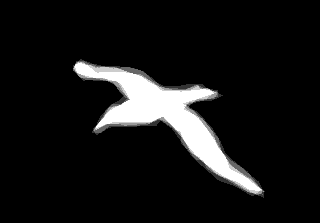

In [14]:
mask_img

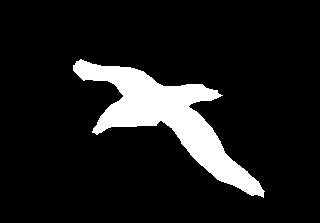

In [15]:
Image.fromarray(binary_mask*255)

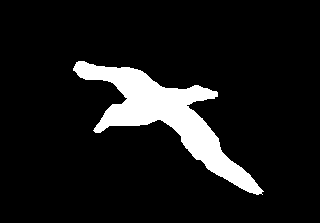

In [16]:
binary_mask=(mask>51).astype(np.uint8)
Image.fromarray(binary_mask*255)

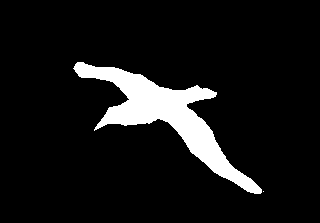

In [17]:
binary_mask=(mask>102).astype(np.uint8)
Image.fromarray(binary_mask*255)

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.c1=nn.Conv2d(in_c,out_c,3,padding=0,bias=True)
        self.c2=nn.Conv2d(out_c,out_c,3,padding=0,bias=True)
        self.r=nn.ReLU(inplace=True)
    def forward(self,x):
        x=self.c1(x)
        x=self.c2(x)
        out=self.r(x)
        return out
    
class Down(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.pool=nn.MaxPool2d(2)
        self.block=DoubleConv(in_c,out_c)
    def forward(self,x):
        x=self.pool(x)
        out=self.block(x)
        return out
        
class UP(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.up=nn.ConvTranspose2d(in_c,in_c//2,2,stride=2)
        self.block=DoubleConv(in_c,out_c)
    def forward(self,x,skip):
        x=self.up(x)
        th,tw=x.shape[-2:]
        Hs,Ws=skip.shape[-2:]
        dh,dw=(Hs-th)//2,(Ws-tw)//2
        skip_c=skip[...,dh:dh+th,dw:dw+tw]
        x=torch.cat([skip_c,x],dim=1)
        out=self.block(x)
        return out

class UNet(nn.Module):
    def __init__(self,in_c=3,n_classes=1,base=64):
        super().__init__()
        self.inc=DoubleConv(in_c,base)
        self.down1=Down(base,base*2)
        self.down2=Down(base*2,base*4)
        self.down3=Down(base*4,base*8)
        self.down4=Down(base*8,base*16)
        self.up1=UP(base*16,base*8)
        self.up2=UP(base*8,base*4)
        self.up3=UP(base*4,base*2)
        self.up4=UP(base*2,base)
        self.outc=nn.Conv2d(base,n_classes,1)

    def forward(self,x):
        #인코딩층
        x1=self.inc(x)
        x2=self.down1(x1)
        x3=self.down2(x2)
        x4=self.down3(x3)
        x5=self.down4(x4)

        #디코더층
        x=self.up1(x5,x4)
        x=self.up2(x,x3)
        x=self.up3(x,x2)
        x=self.up4(x,x1)

        #출력층
        out=self.outc(x)
        return out

In [19]:
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT='./data/CUB_200_2011'
BATCH_SIZE=8
NUM_WORKERS=4
EPOCHS=5
LR=0.005
MOMENTUM=0.9
WEIGHT_DECAY=0.0001

IMG_SIZE=512
N_CLASSES=2
IGNORE_INDEX=255

OUT_DIR='runs'
BEST_PATH='./runs/best_m.pt'
os.makedirs(os.path.dirname(BEST_PATH),exist_ok=True)

import matplotlib.pyplot as plt
BG_COLOR=np.array([50,50,50],dtype=np.uint8)
BIRD_COLOR=np.array([200,50,50],dtype=np.uint8)
IGNORE_COLOR=np.array([100,100,100],dtype=np.uint8)

def _denorm(img):
    mean=torch.tensor([0.485, 0.456, 0.406],device=img.device)[:,None,None]
    std=torch.tensor([0.229, 0.224, 0.225],device=img.device)[:,None,None]
    img = (img*std+mean).clamp(0,1)
    return img.detach().cpu().numpy().transpose(1,2,0)
    
def _colorize_binary(mask_np,ignore_idx=255):
    out=np.zeros((*mask_np.shape,3),dtype=np.uint8)
    out[mask_np == 0]=BG_COLOR
    out[mask_np == 1]=BIRD_COLOR
    out[mask_np == ignore_idx]=IGNORE_COLOR
    return out

def overlay_mask(img_np,mask_rgb,alpha=0.5):
    base=(img_np*255).astype(np.uint8)
    over=(alpha*mask_rgb + (1-alpha)*base).astype(np.uint8)
    return over
@torch.no_grad()
def show_samples(model,loader,batches=1,alpha=0.5,ignore_idx=255,max_rows=None):
    model.eval()
    it=iter(loader)
    for _ in range(batches):
        try:
            batch=next(it)
        except:
            break
        if len(batch)==3:
            x,y,_=batch
        else:
            x,y=batch
        imgs=x.to(DEVICE)
        gts=y.to(DEVICE)

        logits = model(imgs)
        imgs_c=center_crop(imgs,logits.shape[-2:])
        gts_c=center_crop(gts,logits.shape[-2:])
        preds=torch.argmax(logits,dim=1)

        B=imgs.size(0)
        if max_rows is not None:
            B=min(max_rows,B)
        r,c,=B,4
        plt.figure(figsize=(c*4,r*3.5))
        for i in range(B):
            img_np=_denorm(imgs_c[i])
            gt_np = gts_c[i].detach().cpu().numpy()
            pr_np = preds[i].detach().cpu().numpy()
            gt_rgb=_colorize_binary(gt_np)
            pr_rgb=_colorize_binary(pr_np)
            over=overlay_mask(img_np,pr_rgb,alpha)

            base = i*4
            plt.subplot(r,c,base+1)
            plt.imshow(img_np)
            plt.title('img')
            plt.axis('off')
        
            plt.subplot(r,c,base+2)
            plt.imshow(gt_rgb)
            plt.title('t_mask')
            plt.axis('off')

            plt.subplot(r,c,base+3)
            plt.imshow(pr_rgb)
            plt.title('p_mask')
            plt.axis('off')
        
            plt.subplot(r,c,base+4)
            plt.imshow(over)
            plt.title('p_overlay')
            plt.axis('off')
    
        plt.tight_layout()
        plt.show()


In [20]:
def center_crop(t,size_hw):
    H,W=t.shape[-2:]
    th,tw=size_hw
    dh,dw=(H-th)//2,(W-tw)//2
    if t.dim()==4:
        return t[...,dh:dh+th,dw:dw+tw]
    else:
        return t[:,dh:dh+th,dw:dw+tw]

In [21]:
def fast_hist(pred,label,n_class=21,ignore_idx=255):
    mask=label!=ignore_idx
    pred=pred[mask]
    label=label[mask]
    hist=np.bincount(n_class*label.astype(int)+pred.astype(int), minlength=n_class**2).reshape(n_class,n_class).astype(np.float64)
    return hist
    #k=(0<=label) & (label<n_class)
    #return np.bincount(n_class*label[k].astype(int)+pred[k].astype(int), minlength=n_class**2).reshape(n_class,n_class) 
def miou_from_hist(hist):
    iu = np.diag(hist)/(hist.sum(1)+hist.sum(0)-np.diag(hist)+1e-10)
    return float(np.nanmean(iu)),iu

In [22]:

def train(model,criterion,opt,scaler,loader,device,epoch):
    model.train()
    run=0.0
    t0=time.time()
    for x,y in tqdm(loader):
        imgs=x.to(device)
        masks=y.to(device)

        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(imgs)
            masks_c=center_crop(masks,logits.shape[-2:])
            loss = criterion(logits,masks_c.long())
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        run+=loss.item()*imgs.size(0)
    avg_loss = run/len(loader.dataset)
    print(f"[Epoch{epoch}] tr_loss:{avg_loss} t:{time.time()-t0}")
    return avg_loss
@torch.no_grad()
def evaluate(model,loader,device,epoch):
    model.eval()
    hist = np.zeros((N_CLASSES,N_CLASSES),dtype=np.float64)
    for batch in  tqdm(loader):
        if len(batch) == 3:
            x,y,id_=batch
        else:
            x,y=batch
        imgs=x.to(device)
        masks=y.to(device)

        logits = model(imgs)
        masks_c=center_crop(masks,logits.shape[-2:])
        preds=torch.argmax(logits,dim=1)
        hist+= fast_hist(preds.cpu().numpy(),masks_c.cpu().numpy(),N_CLASSES)
    miou, iu = miou_from_hist(hist)
    print(f'[Epoch{epoch}] mIoU:{miou*100:.2f}%')
    return miou

In [23]:
N_CLASSES

2

In [24]:
m=UNet(3,N_CLASSES).to(DEVICE)
criterion=nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
opt=torch.optim.SGD(m.parameters(),lr=LR,momentum=MOMENTUM,weight_decay=WEIGHT_DECAY)
scaler=torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

100%|██████████| 750/750 [01:59<00:00,  6.27it/s]


[Epoch1] tr_loss:0.5852451211100703 t:119.6086277961731


100%|██████████| 725/725 [03:04<00:00,  3.92it/s]

[Epoch1] mIoU:51.92%


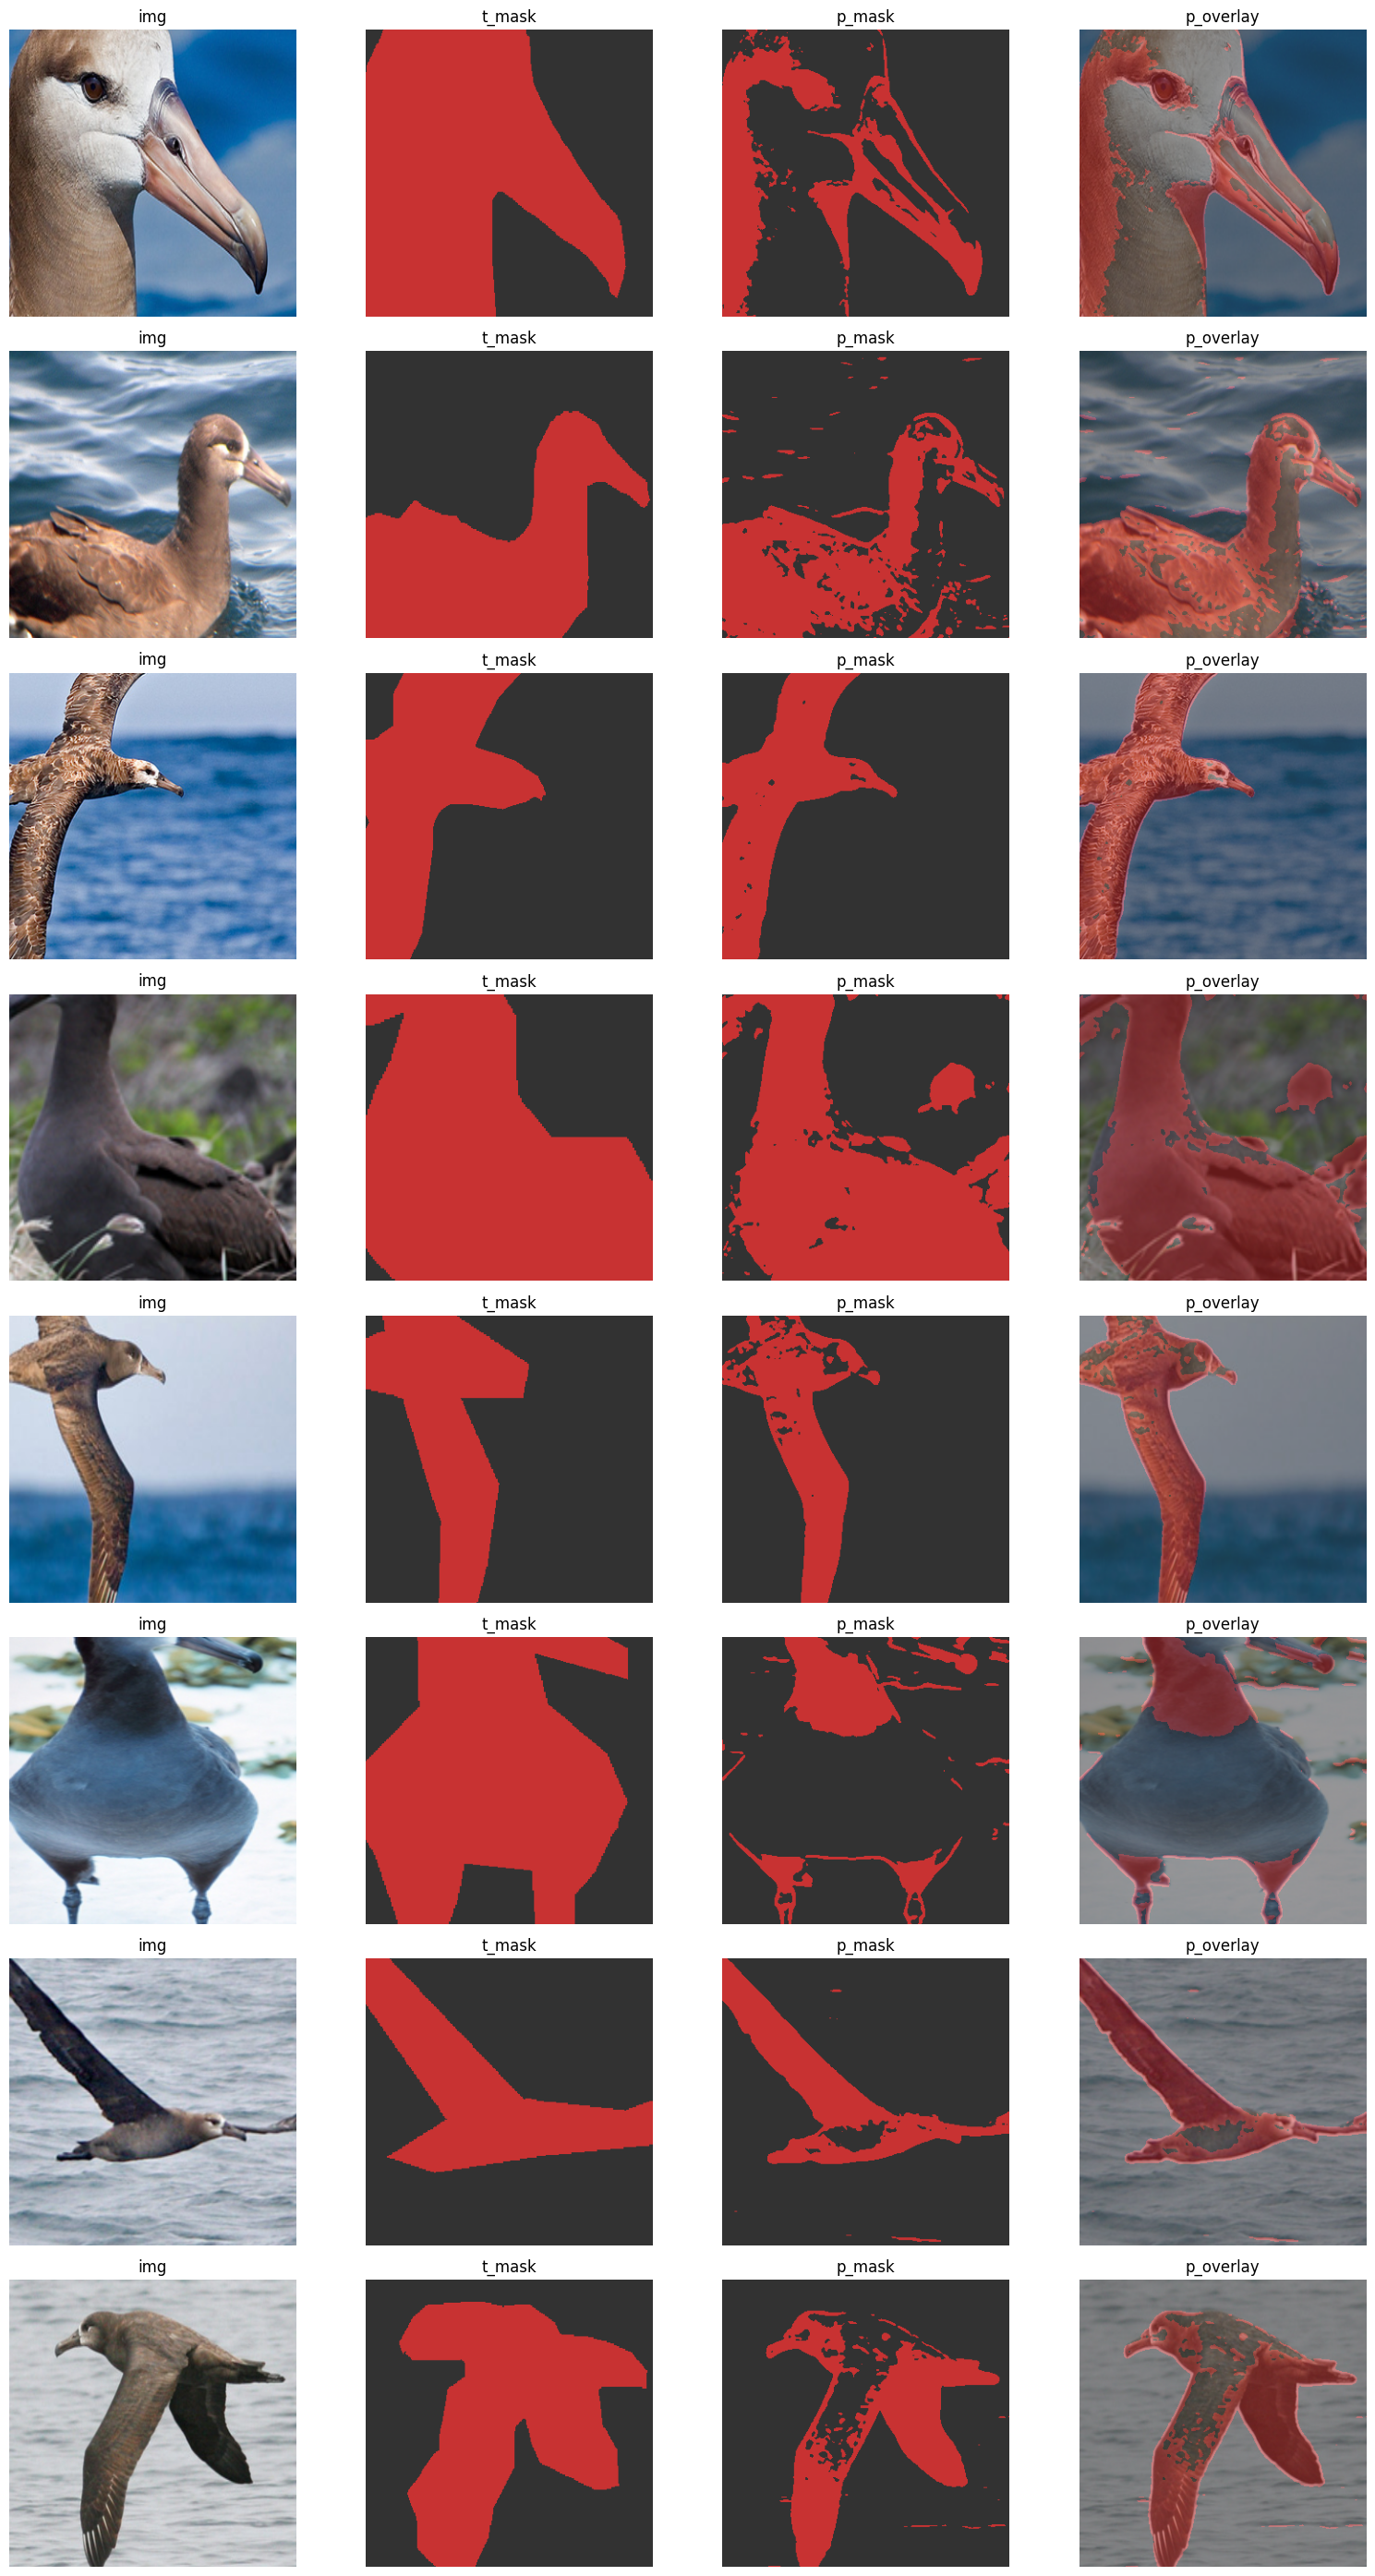

best_m mIoU: 0.5191683357464535 저장 진행


  2%|▏         | 18/750 [00:05<03:42,  3.29it/s]

KeyboardInterrupt



In [25]:
from tqdm import tqdm
best_miou=-1.0
for ep in range(1,EPOCHS+1):
    train(m,criterion,opt,scaler,tr_ds_loader,DEVICE,ep)
    miou=evaluate(m,val_ds_loader,DEVICE,ep)

    #visualize_val_grid_random(ep,m,val_ds,DEVICE,out_dir=OUT_DIR,samples=2)
    #수정할내용
    #model,loader,batches,alpha,ignore_idx,max_rows=None
    show_samples(m,val_ds_loader,1,0.5,IGNORE_INDEX)

    
    if miou>best_miou:
        best_miou=miou
        torch.save(
            {
                'epoch':ep,
                'model':m.state_dict(),
                'miou':best_miou,
                'config':{'IMG_SIZE':IMG_SIZE,
                          'N_CLASSES':N_CLASSES,
                          "LR":LR,
                          "MOMENTUM":MOMENTUM,
                          "WEIGHT_DECAY":WEIGHT_DECAY
                         }
            },BEST_PATH)
        print(f"best_m mIoU: {best_miou} 저장 진행" )

# 지정된 데이터를 이용하여 부류 모델을 만들고 코드를 구조화 하시오
1. 데이터 1 The Oxford-IIIT Pet Dataset.
2. 데이터 2 ISIC2018 Challenge Task1 Data (Segmentation). 
3. 필수 구축 구조
   - 데이터 특성을 고려한 커스텀 데이터셋 클래스
   - 데이터 로더
   - 데이터 전처리기
   - 모델 클래스
   - 학습 중간 시각화
   - 결과를 이용한 데이터 분할 결과 저장(가능한 인원 진행)
4. 모델 성능은 데이터별 1명씩 선정

In [1]:
import os
from pathlib import Path
from PIL import Image
import numpy as np

import torch

from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import functional as TF
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

In [2]:
#데이터 1 The Oxford-IIIT Pet Dataset.
DATA_ROOT='./data/oxford-iiit-pet'
IMAGES_DIR=Path(DATA_ROOT)/'images'/'images'
TRIMAPS_DIR=Path(DATA_ROOT)/'annotations'/'annotations'/'trimaps'
TRAINVAL=Path(DATA_ROOT)/'annotations'/'annotations'/'trainval.txt'
TEST=Path(DATA_ROOT)/'annotations'/'annotations'/'test.txt'
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

OUT_DIR='runs'
BEST_PATH='./runs/best_m.pt'
os.makedirs(os.path.dirname(BEST_PATH),exist_ok=True)
BATCH_SIZE=8
NUM_WORKERS=4
EPOCHS=5
LR=0.001
MOMENTUM=0.9
WEIGHT_DECAY=0.0001

IMG_SIZE=512
N_CLASSES=2
IGNORE_INDEX=255

In [3]:
def make_transform(train):
    def _tfm(img,mask):
        img= TF.resize(img,(IMG_SIZE,IMG_SIZE))
        mask= TF.resize(mask,(IMG_SIZE,IMG_SIZE),interpolation=TF.InterpolationMode.NEAREST)
        if train and torch.rand(1).item()<0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485,0.456,0.406], [0.229,0.224,0.225])
        mask_ck = np.array(mask)
        mask=torch.as_tensor(mask_ck,dtype=torch.long)
        return img,mask
    return _tfm

In [3]:
#np.array(Image.open('data/oxford-iiit-pet/annotations/annotations/trimaps/yorkshire_terrier_200.png'))

In [4]:
#plt.imshow(np.array(Image.open('data/oxford-iiit-pet/annotations/annotations/trimaps/yorkshire_terrier_200.png')))

In [5]:
#np.unique(np.array(Image.open('data/oxford-iiit-pet/annotations/annotations/trimaps/yorkshire_terrier_200.png')))

In [6]:
#{p.stem for p in TRIMAPS_DIR.glob('*.png')}

In [4]:
class OxfordPetsSg(Dataset):
    def __init__(self,img_path,mask_path,stems=None,tf=None,ignore_idx=255):
        self.img_dir=img_path
        self.mask_dir=mask_path
        img_stems={p.stem for p in self.img_dir.glob('*.jpg')}
        mask_stems={p.stem for p in self.mask_dir.glob('*.png')}
        self.stems=sorted(list((img_stems & mask_stems) if stems is None else stems))
        self.tf=tf
        self.ignore_idx=ignore_idx
        
    def __len__(self):
        return len(self.stems)

    def _map_trimap(self,arr):
        if arr.ndim==3:
            arr=arr[...,0]
        out=np.full_like(arr,fill_value=self.ignore_idx,dtype=np.uint8)
        out[arr==1]=1
        out[arr==2]=0
        out[arr==3]=self.ignore_idx
        return out
        
    def __getitem__(self,idx):
        stem=self.stems[idx]
        img=Image.open(self.img_dir/f'{stem}.jpg').convert('RGB')
        mask=Image.open(self.mask_dir/f'{stem}.png')
        mask_np=self._map_trimap(np.array(mask))
        mask=Image.fromarray(mask_np).convert('L')
        
        if self.tf:
            img,mask =self.tf(img,mask)
        else:
            img=TF.to_tensor(img)
            img=TF.normalize(img,[0.485,0.456,0.406], [0.229,0.224,0.225])
            mask=torch.as_tensor(np.array(mask),dtype=torch.long)
        return img,mask 

def read_stems(txt_f):
    with open(txt_f,'r') as f:
        stems=[i.strip().split()[0] for i in f.readlines()]
    return stems

def get_loaders():
    all_stems=read_stems(TRAINVAL)
    n=len(all_stems)
    cut=int(n*0.8)
    tr_stems,val_stems=all_stems[:cut], all_stems[cut:]

    tr_ds=OxfordPetsSg(IMAGES_DIR,TRIMAPS_DIR,tr_stems,make_transform(True),IGNORE_INDEX)
    val_ds=OxfordPetsSg(IMAGES_DIR,TRIMAPS_DIR,val_stems,make_transform(False),IGNORE_INDEX)
    
    tr_ds_loader=DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True,
                            num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
    val_ds_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,
                             num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())

    tt_stems=read_stems(TEST)
    tt_ds=OxfordPetsSg(IMAGES_DIR,TRIMAPS_DIR,tt_stems,make_transform(False),IGNORE_INDEX)
    tt_ds_loader=DataLoader(tt_ds,batch_size=BATCH_SIZE,shuffle=False,
                             num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
    
    return tr_ds,val_ds,tt_ds,tr_ds_loader,val_ds_loader,tt_ds_loader
#tr_ds,val_ds,tt_ds,tr_ds_loader,val_ds_loader,tt_ds_loader=get_loaders()    

In [93]:
#tr_ds,val_ds,tt_ds,tr_ds_loader,val_ds_loader,tt_ds_loader

(<__main__.OxfordPetsSg at 0x7f42c1d06ec0>,
 <torch.utils.data.dataloader.DataLoader at 0x7f42c2d54bb0>)

In [94]:
#x,y=next(iter(tr_ds_loader))

In [95]:
#x.shape

torch.Size([8, 3, 512, 512])

In [96]:
#y.shape

torch.Size([8, 512, 512])

In [5]:
class DoubleConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.c1=nn.Conv2d(in_c,out_c,3,padding=1,bias=True)
        self.c2=nn.Conv2d(out_c,out_c,3,padding=1,bias=True)
        self.r1=nn.ReLU(inplace=True)
        self.r2=nn.ReLU(inplace=True)
    def forward(self,x):
        x=self.c1(x)
        x=self.r1(x)
        x=self.c2(x)
        out=self.r2(x)
        return out
    
class Down(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.pool=nn.MaxPool2d(2)
        self.block=DoubleConv(in_c,out_c)
    def forward(self,x):
        x=self.pool(x)
        out=self.block(x)
        return out
        
class UP(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.up=nn.ConvTranspose2d(in_c,in_c//2,2,stride=2)
        self.block=DoubleConv(in_c,out_c)
    def forward(self,x,skip):
        x=self.up(x)
        th,tw=x.shape[-2:]
        skip=skip[...,:th,:tw]
        x=torch.cat([skip,x],dim=1)
        out=self.block(x)
        return out

class UNet(nn.Module):
    def __init__(self,in_c=3,n_classes=1,base=64):
        super().__init__()
        self.inc=DoubleConv(in_c,base)
        self.down1=Down(base,base*2)
        self.down2=Down(base*2,base*4)
        self.down3=Down(base*4,base*8)
        self.down4=Down(base*8,base*16)
        self.up1=UP(base*16,base*8)
        self.up2=UP(base*8,base*4)
        self.up3=UP(base*4,base*2)
        self.up4=UP(base*2,base)
        self.outc=nn.Conv2d(base,n_classes,1)

    def forward(self,x):
        #인코딩층
        x1=self.inc(x)
        x2=self.down1(x1)
        x3=self.down2(x2)
        x4=self.down3(x3)
        x5=self.down4(x4)

        #디코더층
        x=self.up1(x5,x4)
        x=self.up2(x,x3)
        x=self.up3(x,x2)
        x=self.up4(x,x1)

        #출력층
        out=self.outc(x)
        return out

In [6]:
BG_COLOR=np.array([50,50,50],dtype=np.uint8)
BIRD_COLOR=np.array([200,50,50],dtype=np.uint8)
IGNORE_COLOR=np.array([100,100,100],dtype=np.uint8)

def _denorm(img):
    mean=torch.tensor([0.485, 0.456, 0.406],device=img.device)[:,None,None]
    std=torch.tensor([0.229, 0.224, 0.225],device=img.device)[:,None,None]
    img = (img*std+mean).clamp(0,1)
    return img.detach().cpu().numpy().transpose(1,2,0)
    
def _colorize_binary(mask_np,ignore_idx=255):
    out=np.zeros((*mask_np.shape,3),dtype=np.uint8)
    out[mask_np == 0]=BG_COLOR
    out[mask_np == 1]=BIRD_COLOR
    out[mask_np == ignore_idx]=IGNORE_COLOR
    return out

def overlay_mask(img_np,mask_rgb,alpha=0.5):
    base=(img_np*255).astype(np.uint8)
    over=(alpha*mask_rgb + (1-alpha)*base).astype(np.uint8)
    return over
@torch.no_grad()
def show_samples(model,loader,batches=1,alpha=0.5,ignore_idx=255,max_rows=None):
    model.eval()
    it=iter(loader)
    for _ in range(batches):
        try:
            x,y=next(it)
        except:
            break
        imgs=x.to(DEVICE)
        gts=y.to(DEVICE)

        logits = model(imgs)
        preds=torch.argmax(logits,dim=1)

        B=imgs.size(0)
        if max_rows is not None:
            B=min(max_rows,B)
        r,c,=B,4
        plt.figure(figsize=(c*4,r*3.5))
        for i in range(B):
            img_np=_denorm(imgs[i])
            gt_np = gts[i].detach().cpu().numpy()
            pr_np = preds[i].detach().cpu().numpy()
            gt_rgb=_colorize_binary(gt_np)
            pr_rgb=_colorize_binary(pr_np)
            over=overlay_mask(img_np,pr_rgb,alpha)

            base = i*4
            plt.subplot(r,c,base+1)
            plt.imshow(img_np)
            plt.title('img')
            plt.axis('off')
        
            plt.subplot(r,c,base+2)
            plt.imshow(gt_rgb)
            plt.title('t_mask')
            plt.axis('off')

            plt.subplot(r,c,base+3)
            plt.imshow(pr_rgb)
            plt.title('p_mask')
            plt.axis('off')
        
            plt.subplot(r,c,base+4)
            plt.imshow(over)
            plt.title('p_overlay')
            plt.axis('off')
    
        plt.tight_layout()
        plt.show()

In [7]:
def fast_hist(pred,label,n_class=21,ignore_idx=255):
    mask=label!=ignore_idx
    pred=pred[mask]
    label=label[mask]
    hist=np.bincount(n_class*label.astype(int)+pred.astype(int), 
                     minlength=n_class**2).reshape(n_class,n_class).astype(np.float64)
    return hist
def miou_from_hist(hist):
    iu = np.diag(hist)/(hist.sum(1)+hist.sum(0)-np.diag(hist)+1e-10)
    return float(np.nanmean(iu)),iu

In [8]:
def train(model,criterion,opt,scaler,loader,device,epoch):
    model.train()
    run=0.0
    t0=time.time()
    for x,y in tqdm(loader):
        imgs=x.to(device)
        masks=y.to(device)

        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda',enabled=torch.cuda.is_available()):
            logits = model(imgs)
            loss = criterion(logits,masks.long())
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        run+=loss.item()*imgs.size(0)
    avg_loss = run/len(loader.dataset)
    print(f"[Epoch{epoch}] tr_loss:{avg_loss} t:{time.time()-t0}")
    return avg_loss
@torch.no_grad()
def evaluate(model,loader,device,epoch):
    model.eval()
    hist = np.zeros((N_CLASSES,N_CLASSES),dtype=np.float64)
    for x,y in  tqdm(loader):
        imgs=x.to(device)
        masks=y.to(device)
        logits = model(imgs)
        preds=torch.argmax(logits,dim=1)
        hist+= fast_hist(preds.cpu().numpy(),masks.cpu().numpy(),N_CLASSES)
    miou, iu = miou_from_hist(hist)
    print(f'[Epoch{epoch}] mIoU:{miou*100:.2f}%')
    return miou

In [9]:
tr_ds,val_ds,tt_ds,tr_ds_loader,val_ds_loader,tt_ds_loader=get_loaders()    
m=UNet(3,N_CLASSES).to(DEVICE)
criterion=nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
opt=torch.optim.SGD(m.parameters(),lr=LR,momentum=MOMENTUM,weight_decay=WEIGHT_DECAY)
scaler=torch.amp.GradScaler(enabled=torch.cuda.is_available())

In [11]:
from tqdm import tqdm
import time
best_miou=-1.0
for ep in range(1,EPOCHS+1):
    train(m,criterion,opt,scaler,tr_ds_loader,DEVICE,ep)
    miou=evaluate(m,val_ds_loader,DEVICE,ep)
    show_samples(m,val_ds_loader,1,0.5,IGNORE_INDEX)

    
    if miou>best_miou:
        best_miou=miou
        torch.save(
            {
                'epoch':ep,
                'model':m.state_dict(),
                'miou':best_miou,
                'config':{'IMG_SIZE':IMG_SIZE,
                          'N_CLASSES':N_CLASSES,
                          "LR":LR,
                          "MOMENTUM":MOMENTUM,
                          "WEIGHT_DECAY":WEIGHT_DECAY
                         }
            },BEST_PATH)
        print(f"best_m mIoU: {best_miou} 저장 진행" )
        
ckp=torch.load(BEST_PATH,map_location=DEVICE)
l_m=UNet(3,N_CLASSES).to(DEVICE)
l_m.load_state_dict(ckp['model'])
tt_mIoU=evaluate(l_m,tt_ds_loader,DEVICE,'test')
print(f"test_mIoU:{tt_mIoU}")

  1%|          | 4/368 [00:01<02:07,  2.86it/s]


KeyboardInterrupt: 

In [107]:
#data2 ISIC2018 Challenge Task1 Data (Segmentation).